# EDA — GDELT conflict escalation, Ukraine (`UP`)

Exploratory analysis of the weekly conflict-event panel built by
`src/data/build_weekly_panel.py` and `src/features/feature_engineering.py`.

This notebook is a **thin, read-only wrapper around `src/`** — it imports and
visualizes the already-built weekly/feature panels rather than re-implementing
any logic, so it can never drift out of sync with the pipeline that actually
produces `outputs/`. If the underlying parquet files don't exist yet, run:

```bash
python -m src.data.download_gdelt_bulk
python -m src.data.fetch_google_trends
python -m src.data.build_weekly_panel   # or just: python -m src.pipeline
```

**Contents**
1. Load data
2. Full history: weekly conflict counts & escalation flags
3. Distribution & regime comparison (pre/post initial shock)
4. Tone / sentiment (Goldstein, AvgTone)
5. News volume & the external regressor (Google Trends)
6. Autocorrelation structure (ACF/PACF)
7. Calendar effects
8. Data-quality check (`days_covered`)
9. Feature correlations
10. Target/label distributions
11. Takeaways

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils import load_config, repo_path

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
cfg["country"], cfg["target"]["variant"], cfg["data"]["start_date"], cfg["data"]["end_date"]

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


({'name': 'Ukraine', 'gdelt_code': 'UP'}, 'A', '2022-01-01', '2026-09-07')

## 1. Load data

`weekly_panel` = raw weekly aggregates (before feature engineering).
`feature_df` = full feature panel used by the models (lags, rolling stats,
targets, escalation label, `days_covered` data-quality flag, ...).

In [2]:
weekly_panel = pd.read_parquet(repo_path(cfg["data"]["weekly_panel_path"]))
feature_path = repo_path(cfg["data"]["weekly_panel_path"]).with_name("feature_panel.parquet")
feature_df = pd.read_parquet(feature_path)

for df in (weekly_panel, feature_df):
    df["week_start"] = pd.to_datetime(df["week_start"])

print(f"weekly_panel: {weekly_panel.shape[0]} weeks, {weekly_panel['week_start'].min().date()} .. {weekly_panel['week_start'].max().date()}")
print(f"feature_df:   {feature_df.shape[0]} rows x {feature_df.shape[1]} cols")
weekly_panel.tail()

weekly_panel: 245 weeks, 2021-12-27 .. 2026-08-31
feature_df:   245 rows x 37 cols


,week_start,total_events_country,conflict_count,avg_goldstein,avg_tone,goldstein_volatility,total_mentions_conflict,days_covered,week_label,google_trends_score
240,2026-08-03,9181,2192,-9.890967,-5.819150,0.289747,38740.0,7,2026-W32,8.0
241,2026-08-10,8124,2055,-9.881265,-5.957880,0.304565,23413.0,7,2026-W33,7.0
242,2026-08-17,9457,1930,-9.849482,-6.291071,0.329966,31363.0,7,2026-W34,5.0
243,2026-08-24,10968,1569,-9.871574,-5.558433,0.316301,18807.0,7,2026-W35,6.0
244,2026-08-31,12471,1742,-9.855052,-5.391266,0.333080,40187.0,7,2026-W36,6.0


In [3]:
weekly_panel.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
week_start,245,NaN,NaN,NaN,2024-04-29 00:00:00,2021-12-27 00:00:00,2023-02-27 00:00:00,2024-04-29 00:00:00,2025-06-30 00:00:00,2026-08-31 00:00:00,NaN
total_events_country,245.0,NaN,NaN,NaN,22179.820408,180.0,14115.0,18961.0,25644.0,134050.0,15747.681789
conflict_count,245.0,NaN,NaN,NaN,2738.387755,13.0,1734.0,2491.0,3282.0,12711.0,1612.282569
avg_goldstein,245.0,NaN,NaN,NaN,-9.848009,-9.9375,-9.867188,-9.849928,-9.830923,-9.744569,0.028452
avg_tone,245.0,NaN,NaN,NaN,-4.954887,-6.291071,-5.319392,-4.969252,-4.577761,-3.346087,0.541225
goldstein_volatility,245.0,NaN,NaN,NaN,0.328319,0.232038,0.31232,0.328411,0.344839,0.440872,0.027121
total_mentions_conflict,245.0,NaN,NaN,NaN,35644.2,27.0,18571.0,27826.0,41002.0,269021.0,32522.278285
days_covered,245.0,NaN,NaN,NaN,6.897959,0.0,7.0,7.0,7.0,7.0,0.731182
week_label,245,245,2026-W36,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
google_trends_score,245.0,NaN,NaN,NaN,10.306122,0.0,6.0,8.0,12.0,100.0,9.589108


## 2. Full history: weekly conflict counts & escalation flags

The Feb-2022 invasion produces an enormous, permanent level shift. This single
chart explains most of the modeling difficulty discussed in the README
(structural break, why the 2σ escalation threshold is rare after the shock,
why a strong persistence baseline is hard to beat).

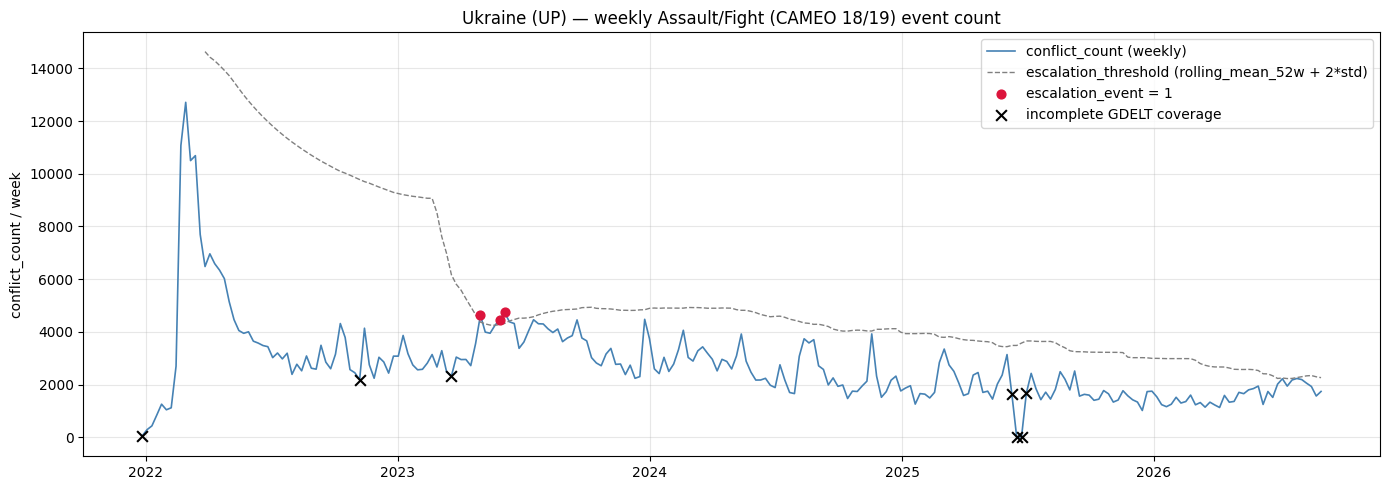

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(feature_df["week_start"], feature_df["conflict_count"], color="steelblue", lw=1.2, label="conflict_count (weekly)")
ax.plot(feature_df["week_start"], feature_df["escalation_threshold"], color="grey", lw=1, ls="--", label="escalation_threshold (rolling_mean_52w + 2*std)")
spikes = feature_df[feature_df["escalation_event"] == 1]
ax.scatter(spikes["week_start"], spikes["conflict_count"], color="crimson", s=40, zorder=5, label="escalation_event = 1")
low_cov = feature_df[feature_df["days_covered"] < 7]
ax.scatter(low_cov["week_start"], low_cov["conflict_count"], marker="x", color="black", s=60, zorder=5, label="incomplete GDELT coverage")
ax.set_title(f"{cfg['country']['name']} ({cfg['country']['gdelt_code']}) — weekly Assault/Fight (CAMEO 18/19) event count")
ax.set_ylabel("conflict_count / week")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 3. Distribution & regime comparison

Split the series into the initial invasion "shock" (first 12 weeks), the first
post-shock year (still settling), and the "current regime" (last 52 weeks) to
make the regime shift concrete rather than just visual.

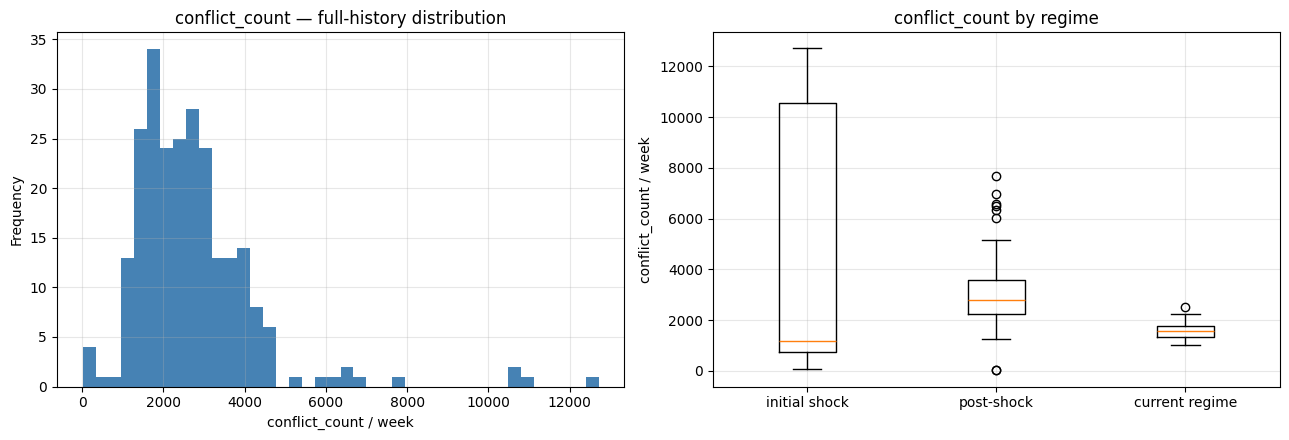

,count,mean,std,min,max
_regime,,,,,
"initial shock (first 12w, Feb-Apr 2022)",12.0,4393.583333,5127.379509,58.0,12711.0
post-shock (weeks 13..end-52),181.0,2955.801105,1131.891919,13.0,7696.0
current regime (last 52w),52.0,1599.653846,331.475660,1019.0,2517.0


In [5]:
n = len(feature_df)
regime = pd.Series("post-shock (weeks 13..end-52)", index=feature_df.index)
regime.iloc[:12] = "initial shock (first 12w, Feb-Apr 2022)"
regime.iloc[-52:] = "current regime (last 52w)"
feature_df["_regime"] = regime.values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
feature_df["conflict_count"].plot(kind="hist", bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("conflict_count — full-history distribution")
axes[0].set_xlabel("conflict_count / week")

order = ["initial shock (first 12w, Feb-Apr 2022)", "post-shock (weeks 13..end-52)", "current regime (last 52w)"]
data = [feature_df.loc[feature_df["_regime"] == r, "conflict_count"] for r in order]
axes[1].boxplot(data, tick_labels=[o.split(" (")[0] for o in order])
axes[1].set_title("conflict_count by regime")
axes[1].set_ylabel("conflict_count / week")
fig.tight_layout()
plt.show()

feature_df.groupby("_regime")["conflict_count"].describe()[["count", "mean", "std", "min", "max"]].reindex(order)

## 4. Tone / sentiment (Goldstein scale, AvgTone)

`avg_goldstein` and `avg_tone` are computed over the **conflict-event subset
only** (root codes 18/19), matching the assignment's SQL example. Goldstein
scale is bounded roughly [-10, +10] (very cooperative to very conflictual);
for Assault/Fight events it sits deeply negative throughout, as expected —
its *volatility*, not its level, is the more informative signal.

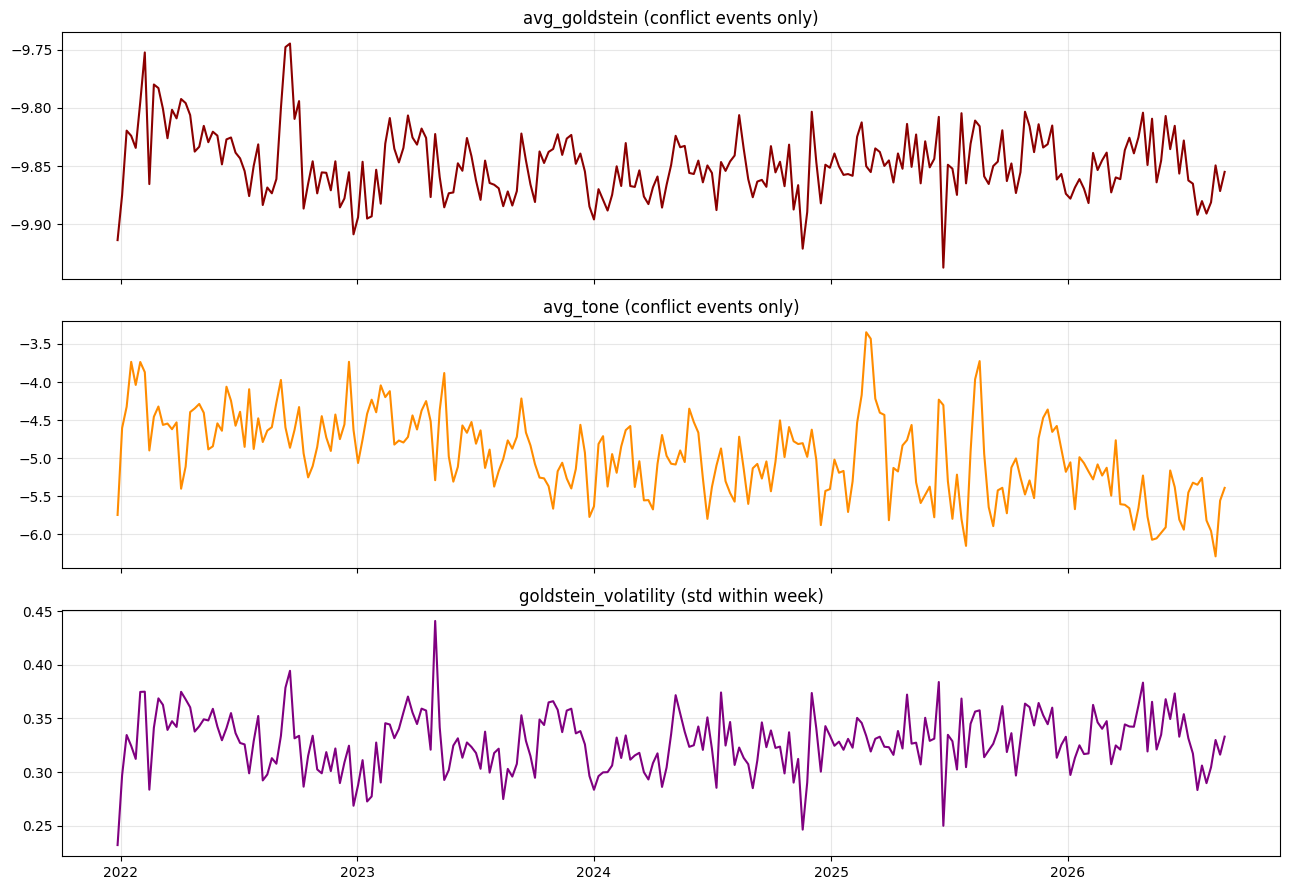

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(feature_df["week_start"], feature_df["avg_goldstein"], color="darkred")
axes[0].set_title("avg_goldstein (conflict events only)")
axes[1].plot(feature_df["week_start"], feature_df["avg_tone"], color="darkorange")
axes[1].set_title("avg_tone (conflict events only)")
axes[2].plot(feature_df["week_start"], feature_df["goldstein_volatility"], color="purple")
axes[2].set_title("goldstein_volatility (std within week)")
fig.tight_layout()
plt.show()

## 5. News volume & the external regressor (Google Trends)

`total_events_country` (all GDELT event types for Ukraine, any CAMEO code) is
a broad news-volume proxy; `google_trends_score` is worldwide search interest
for "Ukraine war". Both should broadly track `conflict_count`, but each also
carries independent noise (global news-cycle competition, search-behavior
shifts) — that's exactly why they're useful as *additional*, not
*replacement*, features.

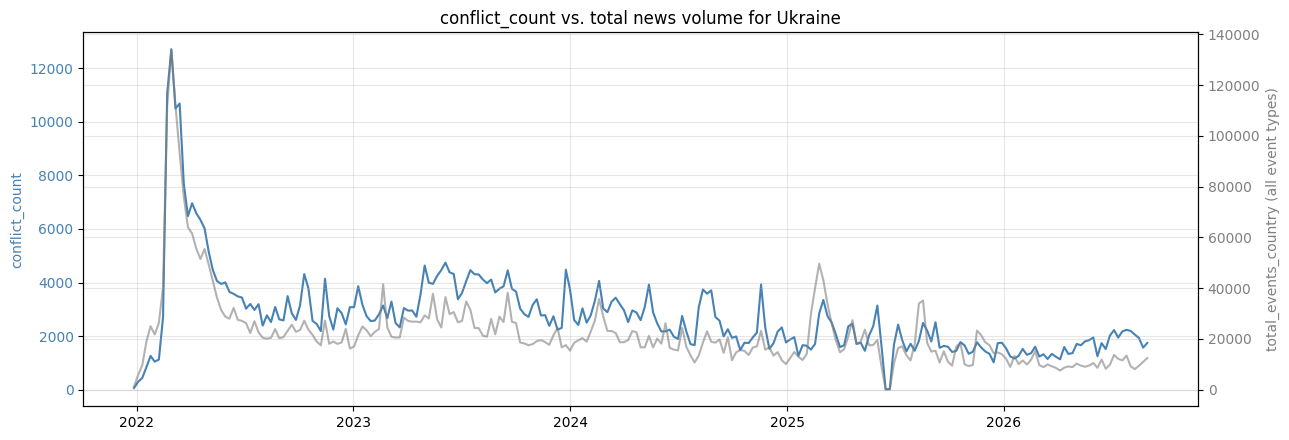

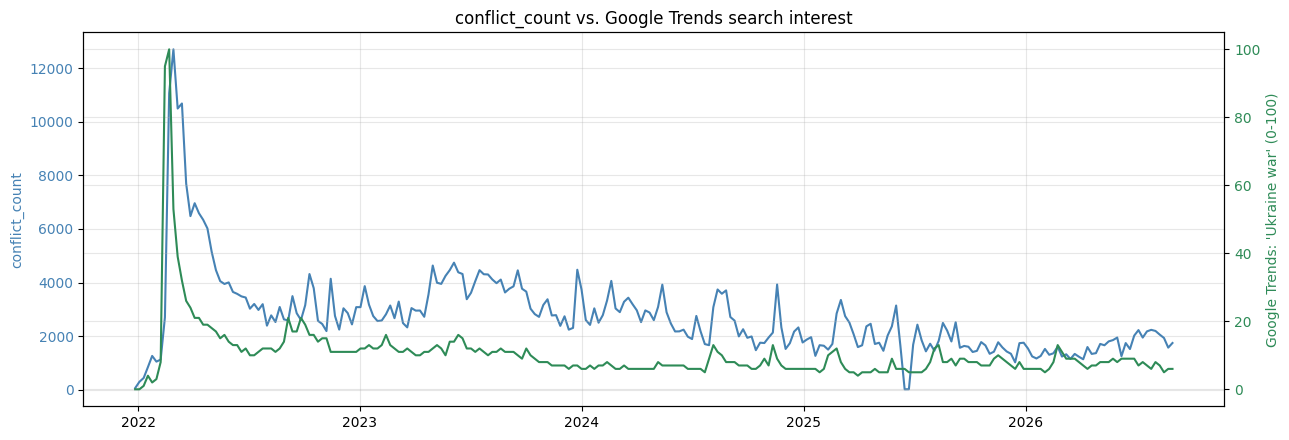

Pearson correlation with conflict_count:
conflict_count          1.000
total_events_country    0.898
google_trends_score     0.632
Name: conflict_count, dtype: float64


In [7]:
fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(feature_df["week_start"], feature_df["conflict_count"], color="steelblue", label="conflict_count")
ax1.set_ylabel("conflict_count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(feature_df["week_start"], feature_df["total_events_country"], color="grey", alpha=0.6, label="total_events_country")
ax2.set_ylabel("total_events_country (all event types)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("conflict_count vs. total news volume for Ukraine")
fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(feature_df["week_start"], feature_df["conflict_count"], color="steelblue", label="conflict_count")
ax1.set_ylabel("conflict_count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(feature_df["week_start"], feature_df["google_trends_score"], color="seagreen", label="google_trends_score")
ax2.set_ylabel("Google Trends: 'Ukraine war' (0-100)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")
ax1.set_title("conflict_count vs. Google Trends search interest")
fig.tight_layout()
plt.show()

corr = feature_df[["conflict_count", "total_events_country", "google_trends_score"]].corr().iloc[0]
print("Pearson correlation with conflict_count:")
print(corr.round(3))

## 6. Autocorrelation structure (ACF/PACF)

Why a persistence/rolling-mean **baseline is so strong** for this series (see
README §8 finding 1): a high lag-1 autocorrelation means "next week ≈ this
week" already captures most of the predictable signal. Computed on the
**post-shock** sub-series (from week 13 onward) so the single enormous 2022
transient doesn't dominate the estimated autocorrelation.

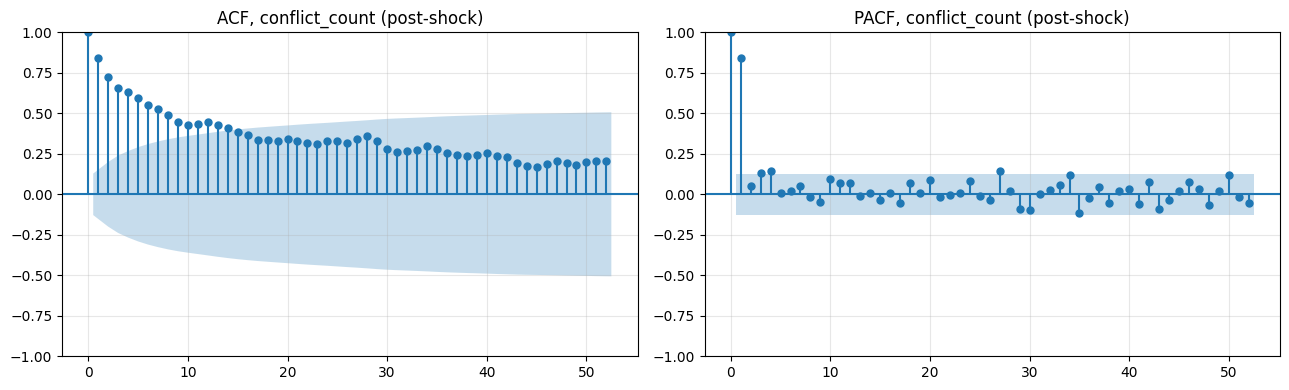

lag-1 autocorrelation (post-shock): 0.879
lag-4 autocorrelation (post-shock): 0.733
lag-52 autocorrelation (post-shock): 0.399  <- weak annual seasonality, explains why ETS underperforms


In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

post_shock = feature_df["conflict_count"].iloc[12:].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(post_shock, lags=52, ax=axes[0])
axes[0].set_title("ACF, conflict_count (post-shock)")
plot_pacf(post_shock, lags=52, method="ywm", ax=axes[1])
axes[1].set_title("PACF, conflict_count (post-shock)")
fig.tight_layout()
plt.show()

print(f"lag-1 autocorrelation (post-shock): {post_shock.autocorr(1):.3f}")
print(f"lag-4 autocorrelation (post-shock): {post_shock.autocorr(4):.3f}")
print(f"lag-52 autocorrelation (post-shock): {post_shock.autocorr(52):.3f}  <- weak annual seasonality, explains why ETS underperforms")

## 7. Calendar effects

Month-of-year pattern on the post-shock sub-series, and a check of the
`is_holiday` flag's relationship with conflict_count (informative mostly for
completeness — GDELT reporting volume is only weakly, if at all, driven by
Ukrainian public holidays).

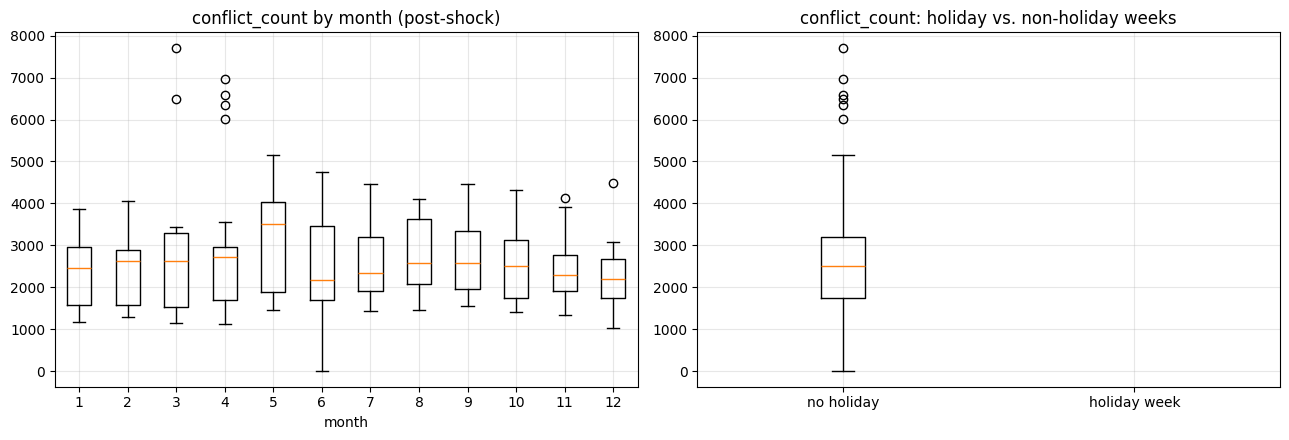

In [9]:
post = feature_df.iloc[12:].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
month_order = list(range(1, 13))
data = [post.loc[post["month"] == m, "conflict_count"] for m in month_order]
axes[0].boxplot(data, tick_labels=month_order)
axes[0].set_title("conflict_count by month (post-shock)")
axes[0].set_xlabel("month")

holiday_data = [post.loc[post["is_holiday"] == v, "conflict_count"] for v in [0, 1]]
axes[1].boxplot(holiday_data, tick_labels=["no holiday", "holiday week"])
axes[1].set_title("conflict_count: holiday vs. non-holiday weeks")
fig.tight_layout()
plt.show()

## 8. Data-quality check: `days_covered`

Every week should have `days_covered == 7` (all 7 daily GDELT files
downloaded successfully). Rows below 7 are weeks with a real, confirmed GDELT
outage (see README §4/§8) — their `conflict_count` is a **lower bound**, and
`feature_engineering.py` masks them out of every `target_count_h{h}` /
`target_event_h{h}` column so no model is trained/scored on a corrupted
value.

In [10]:
incomplete = feature_df.loc[feature_df["days_covered"] < 7,
                             ["week_start", "week_label", "days_covered", "conflict_count"]]
print(f"{len(incomplete)} / {len(feature_df)} weeks have incomplete GDELT coverage:")
incomplete

7 / 245 weeks have incomplete GDELT coverage:


,week_start,week_label,days_covered,conflict_count
0,2021-12-27,2021-W52,2,58
45,2022-11-07,2022-W45,6,2187
64,2023-03-20,2023-W12,6,2325
180,2025-06-09,2025-W24,5,1636
181,2025-06-16,2025-W25,0,13
182,2025-06-23,2025-W26,0,16
183,2025-06-30,2025-W27,5,1678


## 9. Feature correlation heatmap

All columns from `FEATURE_COLUMNS` (the exact feature set the models train
on) plus `conflict_count_t0` for reference. High correlation among the
lag/rolling-stat block is expected (they're all summaries of the same
underlying series at different smoothing horizons) — this is fine for
tree-based models (XGBoost) which are robust to collinearity, and is why we
don't fit a linear model here without regularization.

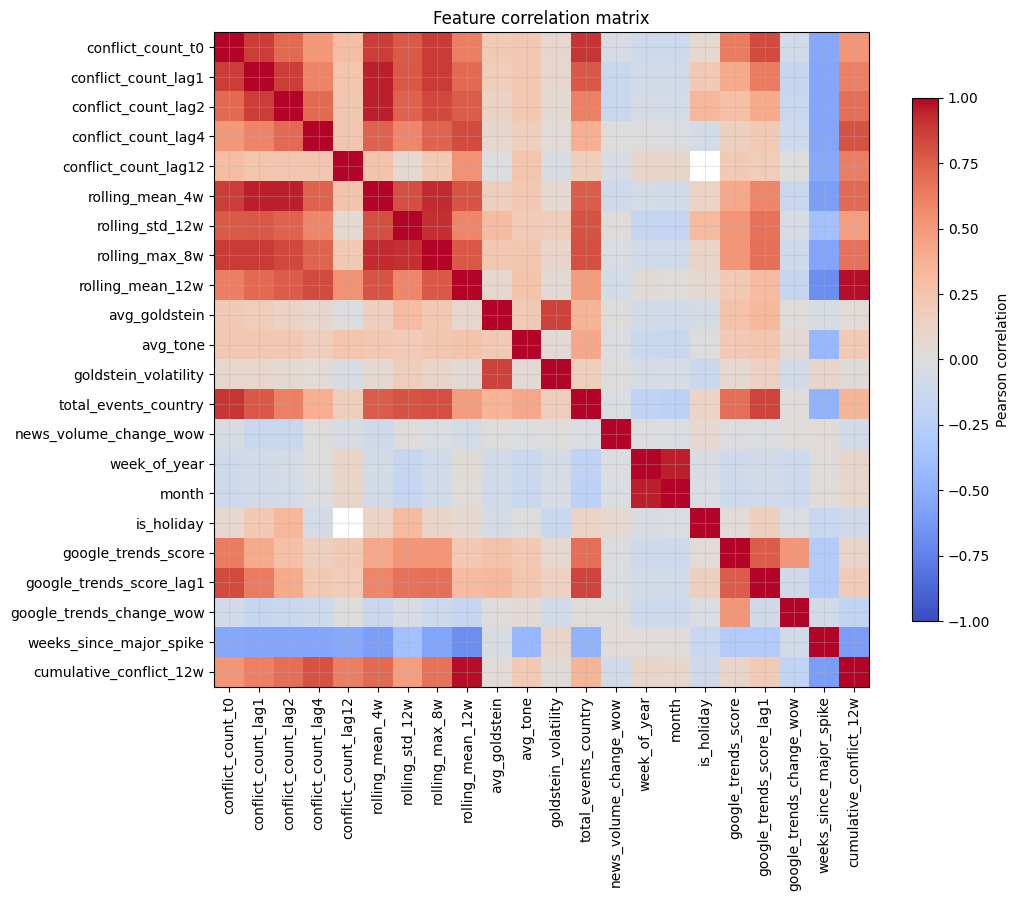

In [11]:
from src.features.feature_engineering import FEATURE_COLUMNS

corr_cols = FEATURE_COLUMNS
corr = feature_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), labels=corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)), labels=corr_cols)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix")
fig.tight_layout()
plt.show()

## 10. Target / label distributions

**Variant A** (`target_count_h1..h4`): distribution barely changes across
horizons (short horizon, same underlying process) — a first hint that a
horizon-invariant baseline should do reasonably well.

**Variant B** (`escalation_event`): count how many weeks are flagged as
escalations in total and see exactly *when* they occur — this is the
concrete evidence behind the "only 3 positive weeks in the whole CV region"
finding in the README.

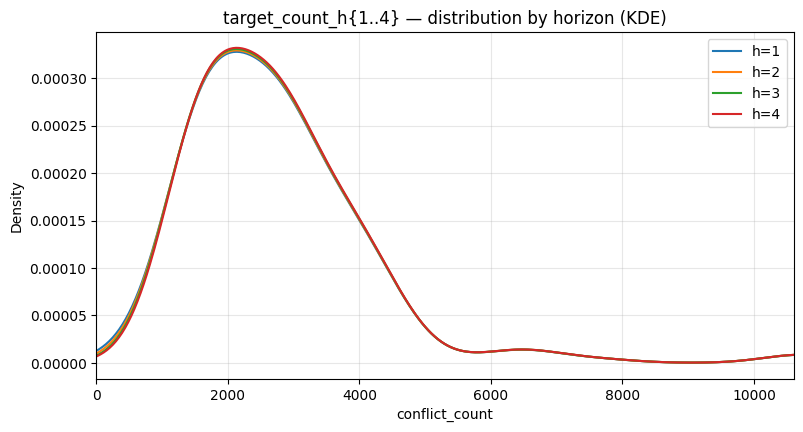

Total escalation_event=1 weeks in the full panel: 3 / 232 scored weeks


,week_start,week_label,conflict_count,escalation_threshold
70,2023-05-01,2023-W18,4636,4372.711973
74,2023-05-29,2023-W22,4464,4278.048101
75,2023-06-05,2023-W23,4743,4320.914324


In [12]:
horizons = cfg["target"]["horizons"]

fig, ax = plt.subplots(figsize=(9, 4.5))
for h in horizons:
    feature_df[f"target_count_h{h}"].plot(kind="kde", ax=ax, label=f"h={h}")
ax.set_xlim(0, feature_df["conflict_count"].quantile(0.99))
ax.set_title("target_count_h{1..4} — distribution by horizon (KDE)")
ax.set_xlabel("conflict_count")
ax.legend()
plt.show()

escalations = feature_df.loc[feature_df["escalation_event"] == 1, ["week_start", "week_label", "conflict_count", "escalation_threshold"]]
print(f"Total escalation_event=1 weeks in the full panel: {len(escalations)} / {feature_df['escalation_event'].notna().sum()} scored weeks")
escalations

## 11. Takeaways

- **Structural break dominates everything.** The Feb-2022 invasion produces a
  ~15x level shift that decays over roughly a year; any rolling-window
  statistic (features, the 2σ threshold) computed across that boundary is
  distorted, and post-shock analysis should generally exclude/discount the
  first ~12-52 weeks.
- **Strong short-lag autocorrelation, weak annual seasonality.** Lag-1
  autocorrelation is high post-shock, lag-52 is weak — this is *why* a
  persistence/rolling-mean baseline is competitive and why a 52-week seasonal
  ETS underperforms (see `02_modeling_and_evaluation.ipynb`).
- **News volume & Google Trends broadly co-move with conflict_count** but are
  clearly noisy, independent proxies (not perfectly correlated) — exactly the
  kind of complementary signal that's useful as engineered features rather
  than a replacement target.
- **Escalation events (Variant B) are extremely rare after the initial
  shock** — only a handful of weeks across ~4.5 years exceed the trailing
  2σ threshold once the window has moved past the war's onset. This is a
  genuine class-imbalance / label-design limitation, not a data bug.
- **A real GDELT data gap (2025-06-14..07-01) is visible and explicitly
  flagged** via `days_covered` — handled by target-masking rather than being
  silently absorbed into the training signal.

Continue to `02_modeling_and_evaluation.ipynb` for the actual model
comparison (baseline / ETS / XGBoost), walk-forward CV, hold-out evaluation,
and the final forecast.